In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
import numpy as np
import random

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training:", x_train.shape)
print("Test:", x_test.shape)

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 99s 1us/step
Training: (50000, 32, 32, 3)
Test: (10000, 32, 32, 3)


In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Pixel range:", x_train.min(), "to", x_train.max())

Pixel range: 0.0 to 1.0


In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=5000,
    random_state=42,
    stratify=y_train
)

print("Training:", x_train.shape)
print("Validation:", x_val.shape)
print("Test:", x_test.shape)

Training: (45000, 32, 32, 3)
Validation: (5000, 32, 32, 3)
Test: (10000, 32, 32, 3)


In [ ]:
import random
import numpy as np
import tensorflow as tf

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed locked:", SEED)

Random seed locked: 42


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),

    # Convolution Block 1
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    tf.keras.layers.Conv2D(256, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Classifier
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 503,306 (1.92 MB)

 Trainable params: 503,306 (1.92 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Baseline CNN compiled successfully!")

Baseline CNN compiled successfully!


In [ ]:
import time

start_time = time.time()

history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_data=(x_val, y_val),
    verbose=1
)

training_time = time.time() - start_time

print(f"\nTraining time: {training_time:.2f} seconds")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.4446 - loss: 1.5217 - val_accuracy: 0.5802 - val_loss: 1.1730
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6073 - loss: 1.1207 - val_accuracy: 0.6704 - val_loss: 0.9512
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6701 - loss: 0.9431 - val_accuracy: 0.6910 - val_loss: 0.8864
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7201 - loss: 0.8109 - val_accuracy: 0.6918 - val_loss: 0.8965
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7535 - loss: 0.7090 - val_accuracy: 0.6944 - val_loss: 0.9043
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7810 - loss: 0.6272 - val_accuracy: 0.7218 - val_loss: 0.8418
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8082 - loss: 0.5507 - val_accuracy: 0.7126 - val_loss: 0.9102
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8345 - loss: 0.4811 - val_accuracy: 

In [ ]:
import os
import json
import numpy as np

save_dir = "/content/drive/MyDrive/CIFAR10_CNN_Project"
os.makedirs(save_dir, exist_ok=True)

# Save trained model
model.save(os.path.join(save_dir, "baseline_cnn.keras"))

# Save training history
np.savez(
    os.path.join(save_dir, "baseline_history.npz"),
    **history.history
)

# Save experiment information
baseline_info = {
    "seed": 42,
    "epochs": 20,
    "batch_size": 64,
    "train_samples": 45000,
    "validation_samples": 5000,
    "test_samples": 10000,
    "parameters": 503306,
    "training_time_seconds": 98.26,
    "final_train_accuracy": 0.9528,
    "final_validation_accuracy": 0.7092,
    "final_train_loss": 0.1343,
    "final_validation_loss": 1.8669
}

with open(os.path.join(save_dir, "baseline_results.json"), "w") as f:
    json.dump(baseline_info, f, indent=4)

print("✅ Baseline model saved successfully!")
print("📁 Location:", save_dir)

✅ Baseline model saved successfully!
📁 Location: /content/drive/MyDrive/CIFAR10_CNN_Project


In [ ]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("\n===== BASELINE TEST RESULTS =====")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7047 - loss: 1.8802

===== BASELINE TEST RESULTS =====
Test Loss: 1.8802
Test Accuracy: 70.47%


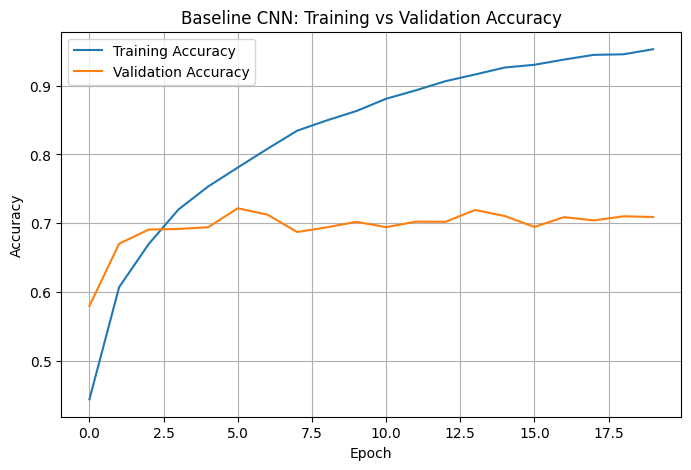

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN: Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

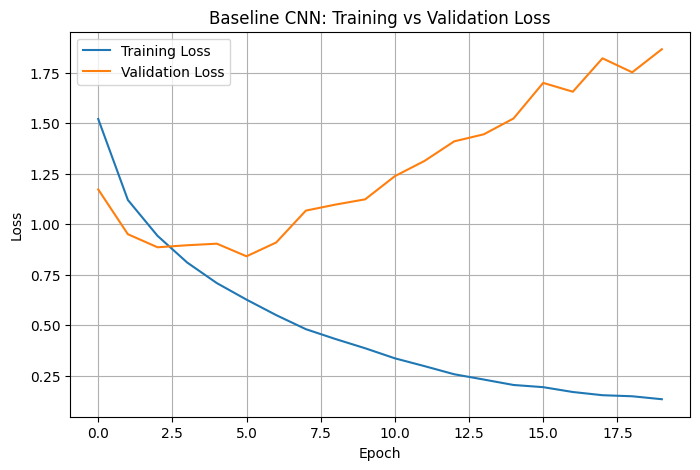

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN: Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np

y_pred_prob = model.predict(x_test, verbose=1)

y_pred = np.argmax(y_pred_prob, axis=1)
y_true = y_test.flatten()

print("Predictions:", y_pred.shape)
print("Actual labels:", y_true.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predictions: (10000,)
Actual labels: (10000,)


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues")
plt.title("Baseline CNN - CIFAR-10 Confusion Matrix")
plt.show()

Confusion Matrix:
[[763  20  46  14  34  11   6  18  54  34]
 [ 24 769   7   8   7  13  13   8  23 128]
 [ 66   4 582  60  97  59  59  49  12  12]
 [ 10  10  73 483  96 162  72  67  12  15]
 [ 13   2  61  47 683  47  45  89   7   6]
 [  6   2  60 131  56 626  21  81   6  11]
 [  6   1  46  49  51  47 758  15  13  14]
 [  9   2  19  29  74  63   5 780   7  12]
 [ 69  21  12  22  16   7   5  12 791  45]
 [ 27  50  10  12   9  24   8  32  16 812]]


NameError: name 'class_names' is not defined

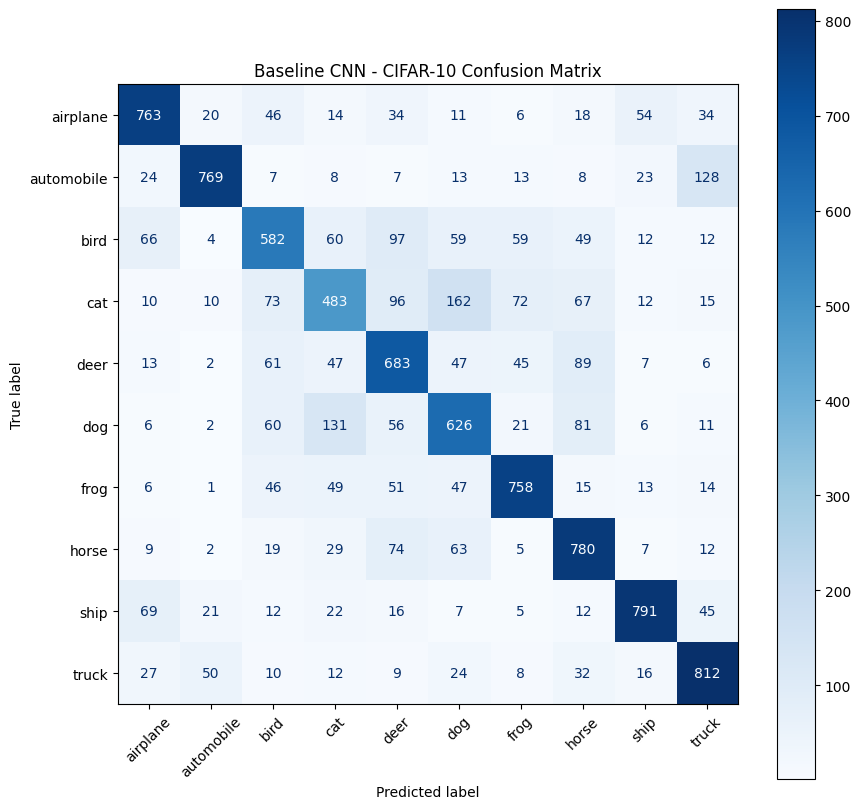

In [ ]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues")
plt.title("Baseline CNN - CIFAR-10 Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

              precision    recall  f1-score   support

    airplane     0.7684    0.7630    0.7657      1000
  automobile     0.8729    0.7690    0.8177      1000
        bird     0.6354    0.5820    0.6075      1000
         cat     0.5649    0.4830    0.5208      1000
        deer     0.6082    0.6830    0.6434      1000
         dog     0.5911    0.6260    0.6081      1000
        frog     0.7641    0.7580    0.7610      1000
       horse     0.6777    0.7800    0.7252      1000
        ship     0.8406    0.7910    0.8150      1000
       truck     0.7456    0.8120    0.7774      1000

    accuracy                         0.7047     10000
   macro avg     0.7069    0.7047    0.7042     10000
weighted avg     0.7069    0.7047    0.7042     10000



In [ ]:
import os
import json
import numpy as np
from sklearn.metrics import classification_report

save_dir = "/content/drive/MyDrive/CIFAR10_CNN_Project"
os.makedirs(save_dir, exist_ok=True)

# Classification report as a dictionary
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

# Complete baseline results
baseline_evaluation = {
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "test_accuracy_percent": float(test_accuracy * 100),
    "training_accuracy": float(history.history["accuracy"][-1]),
    "validation_accuracy": float(history.history["val_accuracy"][-1]),
    "training_loss": float(history.history["loss"][-1]),
    "validation_loss": float(history.history["val_loss"][-1]),
    "training_time_seconds": float(training_time),
    "parameters": model.count_params(),
    "epochs": 20,
    "batch_size": 64,
    "seed": 42,
    "classification_report": report_dict,
    "confusion_matrix": cm.tolist()
}

with open(
    os.path.join(save_dir, "baseline_complete_results.json"),
    "w"
) as f:
    json.dump(baseline_evaluation, f, indent=4)

print("✅ Complete baseline results saved!")
print("📁", os.path.join(save_dir, "baseline_complete_results.json"))

✅ Complete baseline results saved!
📁 /content/drive/MyDrive/CIFAR10_CNN_Project/baseline_complete_results.json
